In [15]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Function to generate realistic sensor readings with small variations
def generate_realistic_data():
    start_time = datetime.now() - timedelta(days=3)  # Start from 3 days ago
    time_intervals = [start_time + timedelta(hours=i) for i in range(72)]  # 72 hourly readings

    # Initialize arrays
    temperature = []
    humidity = []
    moisture = []
    gas_level = []

    # Initial values for slow variation
    base_humidity = 68 + np.random.uniform(-2, 2)
    base_moisture = 23 + np.random.uniform(-1, 1)
    base_gas = 550 + np.random.uniform(-10, 10)

    for i in range(72):
        hour_of_day = (i % 24)  # Simulate daily cycle

        # 🌡 Temperature follows a daily cycle (higher in noon, lower at night)
        temp = 29 + 5 * np.sin((hour_of_day - 6) * np.pi / 12) + np.random.uniform(-1, 1)
        temperature.append(round(temp, 1))

        # 💧 Humidity has slight random fluctuations
        base_humidity += np.random.uniform(-0.5, 0.5)  # Slow variation
        humid = base_humidity - (temp - 27) * 0.7 + np.random.uniform(-1, 1)
        humidity.append(round(humid, 1))

        # 🌱 Moisture has small random drifts but follows humidity
        base_moisture += np.random.uniform(-0.3, 0.3)  # Tiny drift
        moist = base_moisture + (humid - 70) * 0.3 + np.random.uniform(-1, 1)
        moisture.append(round(moist, 1))

        # 🏭 Gas Level slightly increases with moisture but has slow variations
        base_gas += np.random.uniform(-5, 5)  # Tiny variations
        gas = base_gas + (moist - 25) * 8 + np.random.uniform(-10, 10)
        gas_level.append(round(gas, 1))

    # Clip values to realistic ranges
    df = pd.DataFrame({
        "Timestamp": time_intervals,
        "Temperature (°C)": np.clip(temperature, 20, 35),
        "Humidity (%)": np.clip(humidity, 50, 90),
        "Moisture Level (%)": np.clip(moisture, 10, 40),
        "Gas Level (PPM)": np.clip(gas_level, 300, 900)
    })

    return df

# Generate and save as CSV
df = generate_realistic_data()
df.to_csv("grain_storage.csv", index=False)

print("Sample CSV file 'grain_storage.csv' created successfully!")
print(df.head())  # Preview first few rows


Sample CSV file 'grain_storage.csv' created successfully!
                   Timestamp  Temperature (°C)  Humidity (%)  \
0 2025-03-03 14:55:44.193267              23.7          70.5   
1 2025-03-03 15:55:44.193267              24.0          69.5   
2 2025-03-03 16:55:44.193267              24.0          69.2   
3 2025-03-03 17:55:44.193267              25.7          67.8   
4 2025-03-03 18:55:44.193267              27.3          67.1   

   Moisture Level (%)  Gas Level (PPM)  
0                23.1            535.8  
1                21.4            525.5  
2                22.5            541.3  
3                20.6            518.2  
4                20.5            515.6  


In [16]:
df

,Timestamp,Temperature (°C),Humidity (%),Moisture Level (%),Gas Level (PPM)
0,2025-03-03 14:55:44.193267,23.7,70.5,23.1,535.8
1,2025-03-03 15:55:44.193267,24.0,69.5,21.4,525.5
2,2025-03-03 16:55:44.193267,24.0,69.2,22.5,541.3
3,2025-03-03 17:55:44.193267,25.7,67.8,20.6,518.2
4,2025-03-03 18:55:44.193267,27.3,67.1,20.5,515.6
...,...,...,...,...,...
67,2025-03-06 09:55:44.193267,28.5,64.4,21.0,541.2
68,2025-03-06 10:55:44.193267,25.7,66.6,20.2,536.4
69,2025-03-06 11:55:44.193267,25.5,66.2,22.1,557.2
70,2025-03-06 12:55:44.193267,25.4,66.9,21.5,557.4


In [17]:
!pip install seaborn


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


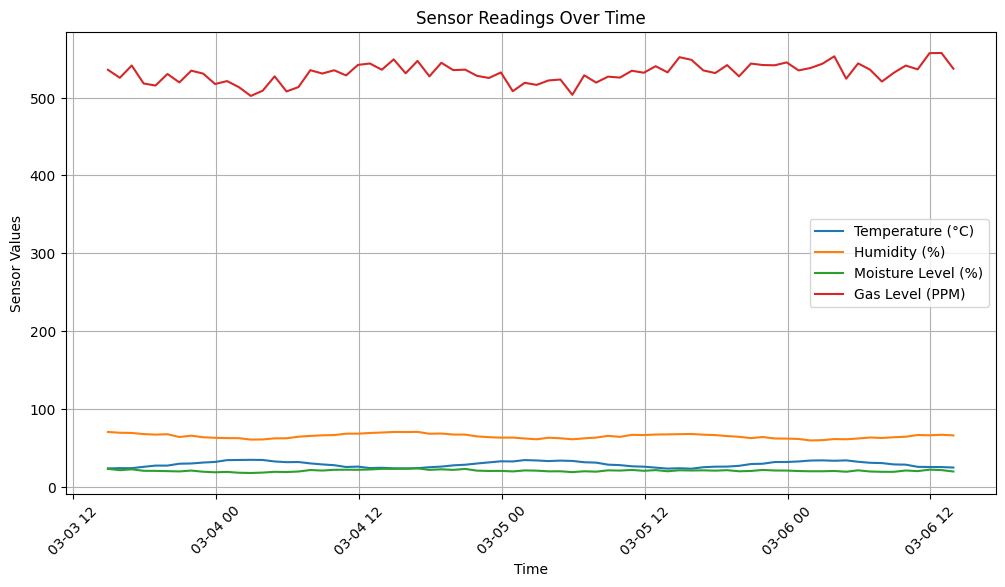

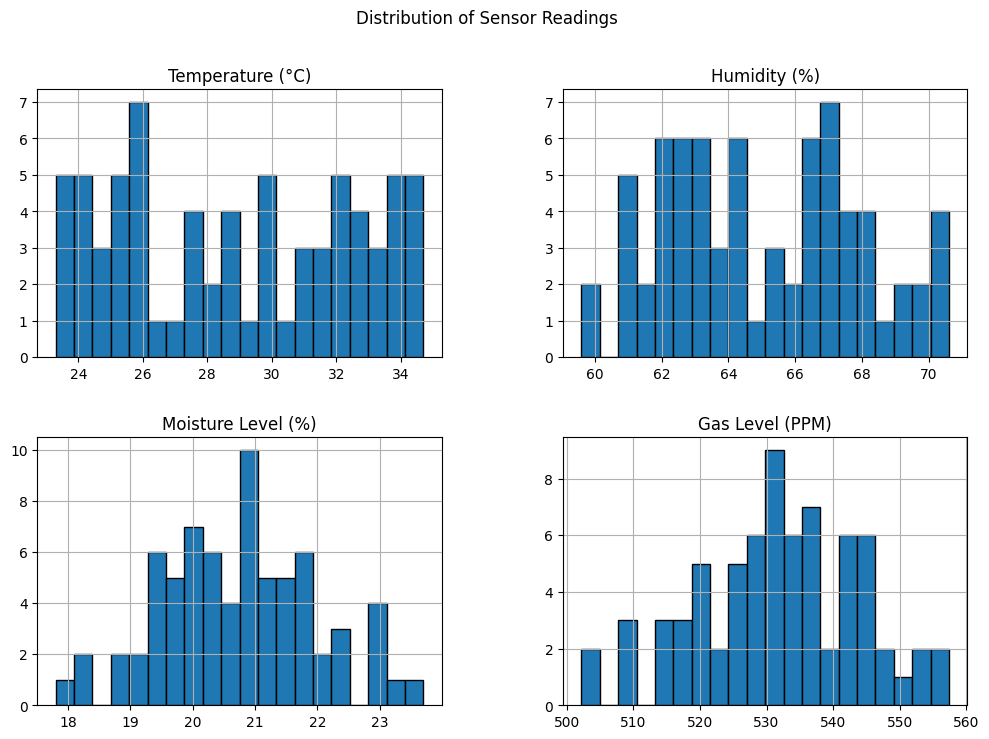

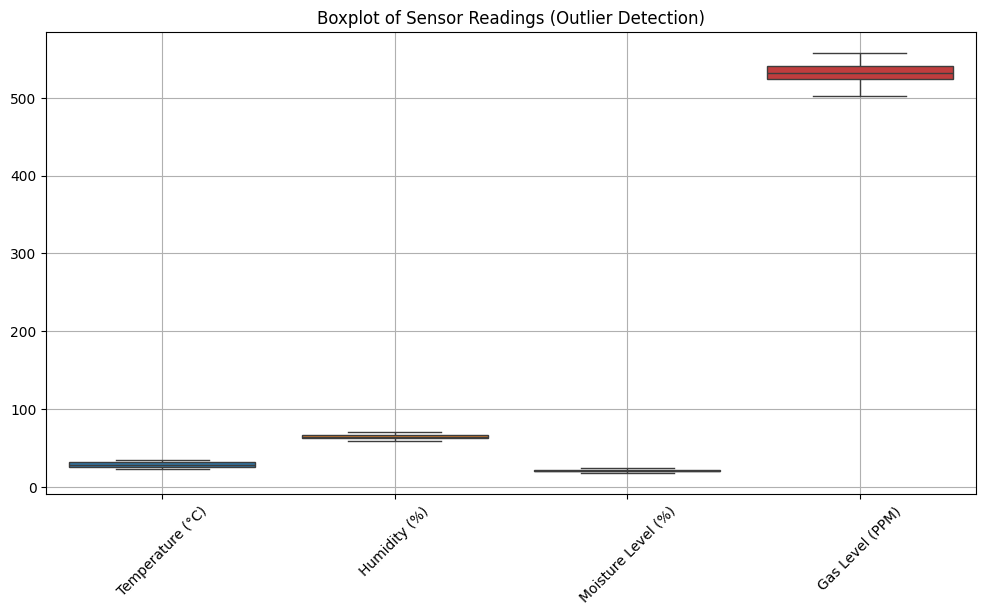

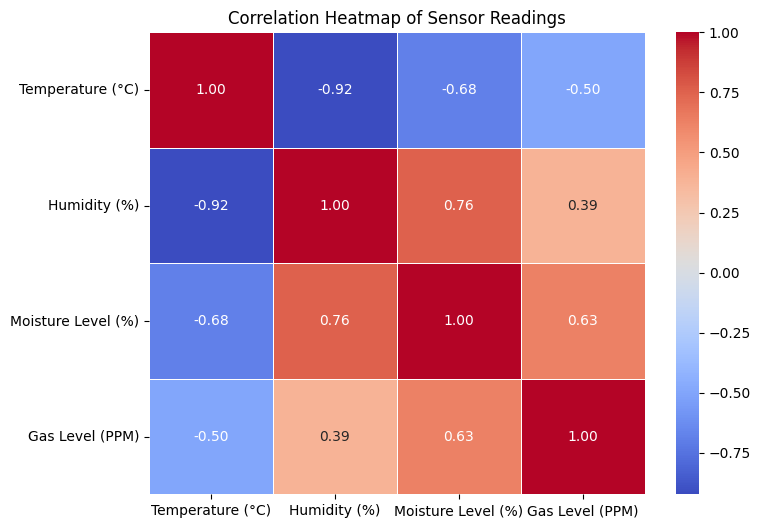

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

df = pd.read_csv("grain_storage.csv")

# Convert timestamp to datetime if needed
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# Set timestamp as index for time-series plots
df.set_index("Timestamp", inplace=True)

# Line Plot: Variation of Temperature, Humidity, Moisture, and Gas Levels over Time
plt.figure(figsize=(12, 6))
for column in df.columns:
    plt.plot(df.index, df[column], label=column)
plt.xlabel("Time")
plt.ylabel("Sensor Values")
plt.title("Sensor Readings Over Time")
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()

# Histogram: Distribution of Each Sensor Reading
df.hist(figsize=(12, 8), bins=20, edgecolor="black")
plt.suptitle("Distribution of Sensor Readings")
plt.show()

# Box Plot: Identifying Outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.title("Boxplot of Sensor Readings (Outlier Detection)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

# Heatmap: Correlation Between Features
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Sensor Readings")
plt.show()

# Scatter Plot: Relationship Between Moisture and Gas Levels (Spoilage Indicator)
# plt.figure(figsize=(8, 6))
# sns.scatterplot(x=df["Moisture Level (%)"], y=df["Gas Level (PPM)"], hue=df.index, palette="coolwarm")
# plt.xlabel("Moisture Level (%)")
# plt.ylabel("Gas Level (PPM)")
# plt.title("Moisture vs Gas Level (Spoilage Risk)")
# plt.grid()
#plt.show()


In [19]:
import pandas as pd

# Load the dataset
df = pd.read_csv("grain_storage.csv")

# Function to classify spoilage risk
def classify_spoilage(temp, humidity):
    if temp > 25 or humidity > 70:
        return "Risky"
    else:
        return "Safe"

# Apply function to create the new column
df["Spoilage Risk"] = df.apply(lambda row: classify_spoilage(row["Temperature (°C)"], row["Humidity (%)"]), axis=1)

# Save the updated dataset
df.to_csv("grain_storage_with_risk.csv", index=False)

print("Updated dataset 'grain_storage_with_risk.csv' created successfully!")
print(df.head())  # Preview first few rows


Updated dataset 'grain_storage_with_risk.csv' created successfully!
                    Timestamp  Temperature (°C)  Humidity (%)  \
0  2025-03-03 14:55:44.193267              23.7          70.5   
1  2025-03-03 15:55:44.193267              24.0          69.5   
2  2025-03-03 16:55:44.193267              24.0          69.2   
3  2025-03-03 17:55:44.193267              25.7          67.8   
4  2025-03-03 18:55:44.193267              27.3          67.1   

   Moisture Level (%)  Gas Level (PPM) Spoilage Risk  
0                23.1            535.8         Risky  
1                21.4            525.5          Safe  
2                22.5            541.3          Safe  
3                20.6            518.2         Risky  
4                20.5            515.6         Risky  


In [20]:
df

,Timestamp,Temperature (°C),Humidity (%),Moisture Level (%),Gas Level (PPM),Spoilage Risk
0,2025-03-03 14:55:44.193267,23.7,70.5,23.1,535.8,Risky
1,2025-03-03 15:55:44.193267,24.0,69.5,21.4,525.5,Safe
2,2025-03-03 16:55:44.193267,24.0,69.2,22.5,541.3,Safe
3,2025-03-03 17:55:44.193267,25.7,67.8,20.6,518.2,Risky
4,2025-03-03 18:55:44.193267,27.3,67.1,20.5,515.6,Risky
...,...,...,...,...,...,...
67,2025-03-06 09:55:44.193267,28.5,64.4,21.0,541.2,Risky
68,2025-03-06 10:55:44.193267,25.7,66.6,20.2,536.4,Risky
69,2025-03-06 11:55:44.193267,25.5,66.2,22.1,557.2,Risky
70,2025-03-06 12:55:44.193267,25.4,66.9,21.5,557.4,Risky


In [21]:
!pip install tensorflow


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
!pip install scikit-learn


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# 🔹 Load the dataset
   # Ensure correct path
df = pd.read_csv("grain_storage_with_risk.csv")

# 🔹 Define Features & Target
features = ["Temperature (°C)", "Humidity (%)", "Moisture Level (%)", "Gas Level (PPM)"]
target = "Spoilage Risk"

# 🔹 Encode Target: Convert "Safe" to 0, "Risky" to 1
df[target] = df[target].map({"Safe": 0, "Risky": 1})

# 🔹 Normalize Features
scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])

# 🔹 Create Sequences for LSTM (Time Series)
sequence_length = 10  # Use last 10 readings to predict the next

def create_sequences(data, target, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])  # Take `sequence_length` rows as input
        y.append(target[i+seq_length])  # Predict the next value
    return np.array(X), np.array(y)

X, y = create_sequences(df[features].values, df[target].values, sequence_length)

# 🔹 Split into Train & Test Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 🔹 Build LSTM Model
model = Sequential([
    Input(shape=(sequence_length, len(features))),  # ✅ Correct Input Layer
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25, activation="relu"),
    Dense(1, activation="sigmoid")  # ✅ Sigmoid for Binary Classification
])

# 🔹 Compile Model
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# 🔹 Train Model
history = model.fit(X_train, y_train, epochs=20, batch_size=16, validation_data=(X_test, y_test))

# 🔹 Save Model
model.save("spoilage_risk_lstm.h5")

print("✅ LSTM model trained and saved successfully!")


Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 159ms/step - accuracy: 0.3053 - loss: 0.7121 - val_accuracy: 0.9231 - val_loss: 0.6615
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8449 - loss: 0.6549 - val_accuracy: 0.9231 - val_loss: 0.6025
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8635 - loss: 0.6055 - val_accuracy: 0.9231 - val_loss: 0.5209
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8510 - loss: 0.5331 - val_accuracy: 0.9231 - val_loss: 0.4210
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8948 - loss: 0.4326 - val_accuracy: 0.9231 - val_loss: 0.3167
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8698 - loss: 0.3723 - val_accuracy: 0.9231 - val_loss: 0.2671
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8760 - loss: 0.3619 - val_accuracy: 0.9231 - val_loss: 0.2775
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8635 - loss: 0.4121 - val_accuracy: 0.9231 - val_loss: 0.2839

✅ LSTM model trained and saved successfully!


In [66]:
print(history.history.keys())

dict_keys([])


In [29]:
test_data= pd.read_csv("new_data.csv")
test_data

,Timestamp,Temperature (°C),Humidity (%),Moisture Level (%),Gas Level (PPM)
0,2025-03-06 08:00:00,24.2,68.7,23.1,525.4
1,2025-03-06 09:00:00,24.5,68.0,21.8,521.0
2,2025-03-06 10:00:00,24.4,68.7,21.3,526.7
3,2025-03-06 11:00:00,25.1,71.8,22.1,531.3
4,2025-03-06 12:00:00,24.2,68.7,23.1,525.4
5,2025-03-06 13:00:00,24.5,68.0,21.8,521.0
6,2025-03-06 14:00:00,24.4,68.7,21.3,526.7
7,2025-03-06 15:00:00,25.1,71.8,22.1,531.3
8,2025-03-06 16:00:00,24.2,68.7,23.1,525.4
9,2025-03-06 17:00:00,24.5,68.0,21.8,521.0


In [73]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler
import joblib  # To load saved scaler

# 🔹 Load the trained model
model = load_model("spoilage_risk_lstm.h5")

# 🔹 Load new sensor data for prediction
new_data = pd.read_csv("new_data.csv")  # Replace with actual new sensor data file

# 🔹 Define Features (Ensure they match training features)
features = ["Temperature (°C)", "Humidity (%)", "Moisture Level (%)", "Gas Level (PPM)"]

# 🔹 Load the SAME SCALER used during training (Ensure you saved it during training)
scaler = joblib.load("scaler.pkl")  # Load the saved scaler

# 🔹 Normalize the new data using the **loaded scaler**
new_data[features] = scaler.transform(new_data[features])  

# 🔹 Create Sequences for LSTM Model
sequence_length = 10

def create_sequences(data, seq_length):
    X = []
    for i in range(len(data) - seq_length + 1):  # Ensure last sequence is included
        X.append(data[i:i+seq_length])
    return np.array(X)

X_new = create_sequences(new_data[features].values, sequence_length)

# 🔹 Make Predictions for **ALL timestamps**
predictions = model.predict(X_new).flatten()  # Convert to 1D array

# 🔹 Convert Predictions to Labels
predicted_labels = ["Risky" if p > 0.5 else "Safe" for p in predictions]

# 🔹 Print Results for Each Hour
for i in range(len(predicted_labels)):
    print(f"Time Index {i}: Spoilage Risk Prediction → {predicted_labels[i]} (Probability: {predictions[i]:.4f})")

    if predicted_labels[i] == "Risky":
        print("⚠️ ALERT: High Spoilage Risk Detected! Take action immediately!")
    else:
        print("✅ All grains are safe. No spoilage risk detected!")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
Time Index 0: Spoilage Risk Prediction → Risky (Probability: 0.8812)
⚠️ ALERT: High Spoilage Risk Detected! Take action immediately!
Time Index 1: Spoilage Risk Prediction → Risky (Probability: 0.8788)
⚠️ ALERT: High Spoilage Risk Detected! Take action immediately!
Time Index 2: Spoilage Risk Prediction → Risky (Probability: 0.8791)
⚠️ ALERT: High Spoilage Risk Detected! Take action immediately!


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler

# 🔹 Load the trained model
model = load_model("spoilage_risk_lstm.h5")

# 🔹 Load new sensor data for prediction
new_data = pd.read_csv("new_data.csv")  # Replace with actual new sensor data file

# 🔹 Define Features (Ensure they match training features)
features = ["Temperature (°C)", "Humidity (%)", "Moisture Level (%)", "Gas Level (PPM)"]

# 🔹 Normalize Features (Use the same scaler as training)
scaler = MinMaxScaler()
new_data[features] = scaler.fit_transform(new_data[features])  # Normalizing input data

# 🔹 Create Sequences for LSTM Model (Same sequence length used during training)
sequence_length = 10

def create_sequences(data, seq_length):
    X = []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
    return np.array(X)

X_new = create_sequences(new_data[features].values, sequence_length)

# 🔹 Make Predictions
predictions = model.predict(X_new)

# 🔹 Convert Predictions to Labels
predicted_labels = ["Risky" if p > 0.5 else "Safe" for p in predictions.flatten()]

# 🔹 Print Results
for i in range(len(predicted_labels)):
    print(f"Time Index {i}: Spoilage Risk Prediction → {predicted_labels[i]}")

    # Print alert if "Risky"
    if predicted_labels[i] == "Risky":
        print("⚠️ ALERT: High Spoilage Risk Detected! Take action immediately!")
    else:
        print("✅ All grains are safe. No spoilage risk detected!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
Time Index 0: Spoilage Risk Prediction → Risky
⚠️ ALERT: High Spoilage Risk Detected! Take action immediately!
Time Index 1: Spoilage Risk Prediction → Risky
⚠️ ALERT: High Spoilage Risk Detected! Take action immediately!


In [62]:
import pandas as pd
import numpy as np

import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.preprocessing import MinMaxScaler
import joblib  # To load saved scaler

# 🔹 Load the trained model
model = load_model("spoilage_risk_lstm.h5")

# 🔹 Load new sensor data for prediction
new_data = pd.read_csv("new_data.csv")  # Replace with actual new sensor data file

# 🔹 Define Features (Ensure they match training features)
features = ["Temperature (°C)", "Humidity (%)", "Moisture Level (%)", "Gas Level (PPM)"]

# 🔹 Load the SAME SCALER used during training (Ensure you saved it during training)
scaler = MinMaxScaler()
new_data[features] = scaler.fit_transform(new_data[features])# Load the saved scaler

# 🔹 Normalize the new data using the **loaded scaler**
new_data[features] = scaler.transform(new_data[features])  

# 🔹 Create Sequences for LSTM Model
sequence_length = 10

def create_sequences(data, seq_length):
    X = []
    for i in range(len(data) - seq_length + 1):  # Ensure last sequence is included
        X.append(data[i:i+seq_length])
    return np.array(X)

X_new = create_sequences(new_data[features].values, sequence_length)

# 🔹 Make Predictions for **ALL timestamps**
predictions = model.predict(X_new).flatten()  # Convert to 1D array

# 🔹 Convert Predictions to Labels
predicted_labels = ["Risky" if p > 0.5 else "Safe" for p in predictions]

# 🔹 Print Results for Each Hour
for i in range(len(predicted_labels)):
    print(f"Time Index {i}: Spoilage Risk Prediction → {predicted_labels[i]} (Probability: {predictions[i]:.4f})")

    if predicted_labels[i] == "Risky":
        print("⚠️ ALERT: High Spoilage Risk Detected! Take action immediately!")
    else:
        print("✅ All grains are safe. No spoilage risk detected!")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
Time Index 0: Spoilage Risk Prediction → Safe (Probability: 0.3476)
✅ All grains are safe. No spoilage risk detected!
Time Index 1: Spoilage Risk Prediction → Safe (Probability: 0.3476)
✅ All grains are safe. No spoilage risk detected!
Time Index 2: Spoilage Risk Prediction → Safe (Probability: 0.3476)
✅ All grains are safe. No spoilage risk detected!


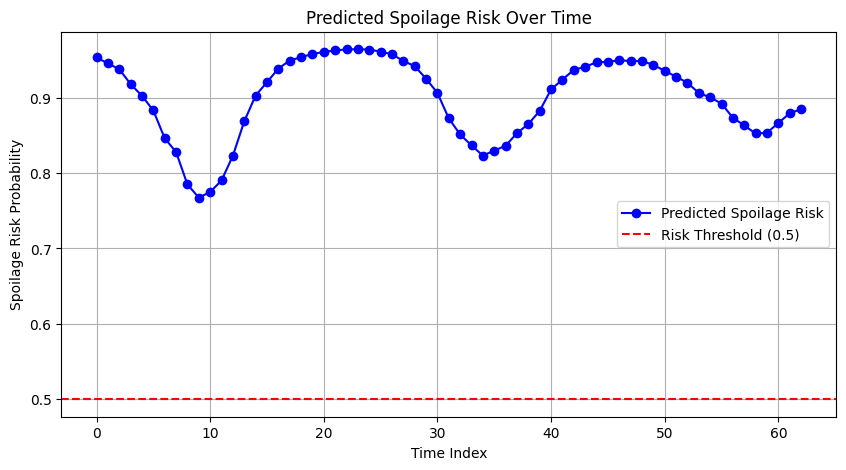

In [72]:
import matplotlib.pyplot as plt

# 🔹 Create a plot for model predictions
plt.figure(figsize=(10, 5))
plt.plot(range(len(predictions)), predictions, marker='o', linestyle='-', color='b', label="Predicted Spoilage Risk")
plt.axhline(y=0.5, color='r', linestyle='--', label="Risk Threshold (0.5)")  # Threshold line
plt.xlabel("Time Index")
plt.ylabel("Spoilage Risk Probability")
plt.title("Predicted Spoilage Risk Over Time")
plt.legend()
plt.grid(True)
plt.show()


Training Model on Three Month Dataset

In [23]:
import pandas as pd
import numpy as np

# Define date range: hourly from Feb 1 to Apr 30
date_range = pd.date_range(start="2024-02-01", end="2024-04-30 23:00:00", freq='H')

# Lists to store generated data
temperatures = []
humidities = []

# Generate synthetic data
for timestamp in date_range:
    month = timestamp.month
    hour = timestamp.hour

    # Temperature: warmer during the day, cooler at night
    if 6 <= hour <= 18:
        base_temp = np.random.uniform(20, 35)
    else:
        base_temp = np.random.uniform(10, 20)

    temp = base_temp + np.random.normal(0, 1.5)  # Add random fluctuation
    temperatures.append(round(temp, 2))

    # Humidity based on monthly trend
    if month == 2:
        base_humidity = np.random.uniform(42, 50)
    elif month == 3:
        base_humidity = np.random.uniform(32, 38)
    else:  # April
        base_humidity = np.random.uniform(52, 62)

    # Lower humidity during the day
    if 6 <= hour <= 18:
        base_humidity -= np.random.uniform(1, 3)

    humidity = base_humidity + np.random.normal(0, 1.2)
    humidity = round(max(20, min(humidity, 100)), 2)  # Clamp values
    humidities.append(humidity)

# Create DataFrame
df1 = pd.DataFrame({
    "Timestamp": date_range,
    "Location_ID": "Room_1",
    "Temperature_C": temperatures,
    "Humidity_%": humidities
})

# Save to CSV
df1.to_csv("three_month_data.csv", index=False)
print("CSV file 'synthetic_iot_weather_data.csv' generated successfully.")


CSV file 'synthetic_iot_weather_data.csv' generated successfully.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_14324\3140949362.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_range = pd.date_range(start="2024-02-01", end="2024-04-30 23:00:00", freq='H')


In [24]:
df1.head()

,Timestamp,Location_ID,Temperature_C,Humidity_%
0,2024-02-01 00:00:00,Room_1,15.14,45.92
1,2024-02-01 01:00:00,Room_1,15.27,47.78
2,2024-02-01 02:00:00,Room_1,13.28,45.50
3,2024-02-01 03:00:00,Room_1,14.74,48.25
4,2024-02-01 04:00:00,Room_1,18.41,46.51


In [26]:
df1.describe()

,Timestamp,Temperature_C,Humidity_%
count,2160,2160.000000,2160.000000
mean,2024-03-16 23:29:59.999999744,21.784690,44.788764
min,2024-02-01 00:00:00,6.600000,26.980000
25%,2024-02-23 11:45:00,15.407500,35.367500
50%,2024-03-16 23:30:00,21.030000,44.785000
75%,2024-04-08 11:15:00,28.137500,53.540000
max,2024-04-30 23:00:00,38.530000,64.200000
std,NaN,7.426651,9.488851


Training LSTM 

Temperature as only variable


In [2]:
from sklearn.preprocessing import MinMaxScaler

# Example: using Temperature as target
data = df[['Temperature_C']].values
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)


In [ ]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

sequence_length = 24 # e.g., use past 24 hours to predict next hour
X, y = create_sequences(data_scaled, sequence_length)


In [8]:
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [11]:
from keras.models import Sequential
from keras.layers import LSTM, Dense

model = Sequential([
    LSTM(128, input_shape=(X_train.shape[1], 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/10


C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.1049 - val_loss: 0.0444
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0432 - val_loss: 0.0282
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0268 - val_loss: 0.0249
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0260 - val_loss: 0.0239
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0246 - val_loss: 0.0238
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0239 - val_loss: 0.0237
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0255 - val_loss: 0.0234
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0245 - val_loss: 0.0240
Epoch 9/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0245 - val_loss: 0.0255
Epoch 10/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0243 - val_loss: 0.0235


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test)

mae = mean_absolute_error(y_test_inv, y_pred_inv)
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100

print(f"MAE: {mae:.3f}, MSE: {mse:.3f}, RMSE: {rmse:.3f}, MAPE: {mape:.2f}%")


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
MAE: 3.973, MSE: 24.964, RMSE: 4.996, MAPE: 20.71%


Temperature + Humidity

In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Load your dataset
df = pd.read_csv("three_month_data.csv")

# Ensure datetime is parsed correctly
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Create cyclical time features from hour
df['hour'] = df['Timestamp'].dt.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df.drop(columns=['hour'], inplace=True)  # optional

# Select only relevant columns
features = ['Temperature_C', 'Humidity_%', 'hour_sin', 'hour_cos']
data = df[features]

# Normalize features
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Create sequences
def create_sequences(data, time_steps=24):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps][0])  # target = temperature
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Build LSTM model
model = Sequential()
model.add(LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1)


Epoch 1/50


C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0736 - val_loss: 0.0212
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0279 - val_loss: 0.0207
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0262 - val_loss: 0.0210
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0251 - val_loss: 0.0301
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0285 - val_loss: 0.0203
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0243 - val_loss: 0.0207
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0241 - val_loss: 0.0200
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0242 - val_loss: 0.0202
Epoch 9/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0235 - val_loss: 0.0205
Epoch 10/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0258 - val_loss: 0.0200
Epoch 11/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0240 - val_loss: 0.0201
Epoch 12/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0249 - val_loss: 0.0198

In [22]:
df.head()

,Timestamp,Location_ID,Temperature_C,Humidity_%,hour_sin,hour_cos
0,2024-02-01 00:00:00,Room_1,9.15,49.03,0.000000,1.000000
1,2024-02-01 01:00:00,Room_1,17.07,46.89,0.258819,0.965926
2,2024-02-01 02:00:00,Room_1,16.90,44.38,0.500000,0.866025
3,2024-02-01 03:00:00,Room_1,13.14,51.04,0.707107,0.707107
4,2024-02-01 04:00:00,Room_1,9.36,44.22,0.866025,0.500000


In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Predict on test set
y_pred = model.predict(X_test)

# Prepare full arrays for inverse_transform (assuming scaler was fit on 4 features)
y_pred_full = np.zeros((len(y_pred), scaled_data.shape[1]))
y_test_full = np.zeros((len(y_test), scaled_data.shape[1]))

y_pred_full[:, 0] = y_pred.ravel()  # only temperature was predicted
y_test_full[:, 0] = y_test.ravel()  # actual temperature

# Inverse transform to get temperature values in original scale
y_pred_inv = scaler.inverse_transform(y_pred_full)[:, 0]
y_test_inv = scaler.inverse_transform(y_test_full)[:, 0]

# Compute error metrics
mae = mean_absolute_error(y_test_inv, y_pred_inv)
mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100

# Print results
print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAPE: {mape:.2f}%")


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
MAE: 3.774
MSE: 22.660
RMSE: 4.760
MAPE: 18.67%


WOA Optimization (Whale Optimization Algorithm)


In [32]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Load and preprocess data (same as before)
df = pd.read_csv("three_month_data.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['hour'] = df['Timestamp'].dt.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df.drop(columns=['hour'], inplace=True)

features = ['Temperature_C', 'Humidity_%', 'hour_sin', 'hour_cos']
data = df[features]
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

def create_sequences(data, time_steps=24):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps][0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# WOA Implementation
def woa_optimize_lstm(X_train, y_train, X_test, y_test, population_size=8, max_iter=10):
    # Define search space for hyperparameters
    search_space = {
        'lstm_units': (32, 128),
        'dropout_rate': (0.1, 0.5),
        'batch_size': (16, 64),
        'learning_rate': (0.0001, 0.01)
    }
    
    # Initialize whale population
    population = []
    for _ in range(population_size):
        whale = {
            'lstm_units': np.random.randint(*search_space['lstm_units']),
            'dropout_rate': np.random.uniform(*search_space['dropout_rate']),
            'batch_size': np.random.randint(*search_space['batch_size']),
            'learning_rate': np.random.uniform(*search_space['learning_rate']),
            'fitness': np.inf
        }
        population.append(whale)
    
    # Find the best whale initially
    best_whale = min(population, key=lambda x: x['fitness'])
    
    # WOA main loop
    for iteration in range(max_iter):
        a = 2 - iteration * (2 / max_iter)  # a decreases linearly from 2 to 0
        a2 = -1 + iteration * (-1 / max_iter)  # a2 linearly decreases from -1 to -2
        
        for i in range(population_size):
            # Update current whale
            r1 = np.random.random()
            r2 = np.random.random()
            
            A = 2 * a * r1 - a
            C = 2 * r2
            b = 1  # defines the shape of the spiral
            l = (a2 - 1) * np.random.random() + 1
            
            p = np.random.random()
            
            # Update parameters
            for param in search_space.keys():
                if p < 0.5:
                    if abs(A) < 1:
                        # Shrinking encircling mechanism
                        D = abs(C * best_whale[param] - population[i][param])
                        population[i][param] = best_whale[param] - A * D
                    else:
                        # Search for prey
                        rand_whale = population[np.random.randint(0, population_size)]
                        D = abs(C * rand_whale[param] - population[i][param])
                        population[i][param] = rand_whale[param] - A * D
                else:
                    # Spiral updating position
                    D = abs(best_whale[param] - population[i][param])
                    population[i][param] = D * np.exp(b * l) * np.cos(2 * np.pi * l) + best_whale[param]
                
                # Ensure parameters stay within bounds
                if param in ['lstm_units', 'batch_size']:
                    population[i][param] = int(np.clip(population[i][param], search_space[param][0], search_space[param][1]))
                else:
                    population[i][param] = np.clip(population[i][param], search_space[param][0], search_space[param][1])
            
            # Evaluate fitness
            model = build_lstm_model(population[i], X_train.shape[1], X_train.shape[2])
            early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
            history = model.fit(X_train, y_train, 
                              epochs=50, 
                              batch_size=int(population[i]['batch_size']), 
                              validation_split=0.1, 
                              callbacks=[early_stop],
                              verbose=0)
            
            val_loss = min(history.history['val_loss'])
            population[i]['fitness'] = val_loss
            
            # Update best whale
            if val_loss < best_whale['fitness']:
                best_whale = population[i].copy()
        
        print(f"Iteration {iteration+1}, Best Fitness: {best_whale['fitness']:.4f}")
    
    return best_whale

def build_lstm_model(params, time_steps, n_features):
    model = Sequential()
    model.add(LSTM(int(params['lstm_units']), input_shape=(time_steps, n_features), return_sequences=False))
    model.add(Dropout(params['dropout_rate']))
    model.add(Dense(1))
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=params['learning_rate'])
    model.compile(optimizer=optimizer, loss='mse')
    return model

# Run WOA optimization
print("Starting WOA optimization...")
best_params = woa_optimize_lstm(X_train, y_train, X_test, y_test)
print("\nOptimization completed. Best parameters found:")
print(best_params)

# Build and train final model with best parameters
final_model = build_lstm_model(best_params, X_train.shape[1], X_train.shape[2])
history = final_model.fit(X_train, y_train, 
                         epochs=100, 
                         batch_size=int(best_params['batch_size']), 
                         validation_split=0.1,
                         callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)])

# Evaluate the optimized model
y_pred = final_model.predict(X_test)

# Inverse transform predictions and actual values
y_test_actual = scaler.inverse_transform(np.concatenate([y_test.reshape(-1,1), np.zeros((len(y_test), len(features)-1))], axis=1))[:,0]
y_pred_actual = scaler.inverse_transform(np.concatenate([y_pred.reshape(-1,1), np.zeros((len(y_pred), len(features)-1))], axis=1))[:,0]

# Calculate error metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

print("\nOptimized Model Performance:")
print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAPE: {mape:.2f}%")



Starting WOA optimization...


C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Iteration 1, Best Fitness: 0.0235
Iteration 2, Best Fitness: 0.0231
Iteration 3, Best Fitness: 0.0228
Iteration 4, Best Fitness: 0.0227
Iteration 5, Best Fitness: 0.0227
Iteration 6, Best Fitness: 0.0227
Iteration 7, Best Fitness: 0.0209
Iteration 8, Best Fitness: 0.0203
Iteration 9, Best Fitness: 0.0203
Iteration 10, Best Fitness: 0.0203

Optimization completed. Best parameters found:
{'lstm_units': 59, 'dropout_rate': 0.20730669904980364, 'batch_size': 19, 'learning_rate': 0.001068850180747917, 'fitness': 0.020291054621338844}
Epoch 1/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0726 - val_loss: 0.0256
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0279 - val_loss: 0.0254
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0270 - val_loss: 0.0246
Epoch 4/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0258 - val_loss: 0.0275
Epoch 5/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0261 - val_loss: 0.0268
Epoch 6/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0

PSO Optimization (Particle Swarm Optimization)


In [36]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# PSO Implementation
class PSO:
    def __init__(self, n_particles, dimensions, bounds, X_train, y_train, X_val, y_val, max_iter=20):
        self.n_particles = n_particles
        self.dimensions = dimensions
        self.bounds = bounds
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val
        self.max_iter = max_iter
        
        # PSO parameters
        self.w = 0.729  # inertia weight
        self.c1 = 1.49445  # cognitive weight
        self.c2 = 1.49445  # social weight
        
        # Initialize particles
        self.particles = np.random.uniform(low=[b[0] for b in bounds],
                                          high=[b[1] for b in bounds],
                                          size=(n_particles, dimensions))
        
        # Initialize velocities
        self.velocities = np.zeros((n_particles, dimensions))
        
        # Initialize best positions and scores
        self.pbest_positions = self.particles.copy()
        self.pbest_scores = np.array([float('inf')] * n_particles)
        
        # Initialize global best
        self.gbest_position = None
        self.gbest_score = float('inf')
        
    def evaluate(self, particle):
        """Build and evaluate LSTM model with given hyperparameters"""
        lstm_units = int(particle[0])
        dropout_rate = particle[1]
        learning_rate = particle[2]
        batch_size = int(particle[3])
        
        model = Sequential()
        model.add(LSTM(lstm_units, input_shape=(self.X_train.shape[1], self.X_train.shape[2]), return_sequences=False))
        model.add(Dropout(dropout_rate))
        model.add(Dense(1))
        
        optimizer = Adam(learning_rate=learning_rate)
        model.compile(optimizer=optimizer, loss='mse')
        
        early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        
        history = model.fit(self.X_train, self.y_train,
                          epochs=30,
                          batch_size=batch_size,
                          validation_data=(self.X_val, self.y_val),
                          callbacks=[early_stop],
                          verbose=0)
        
        return min(history.history['val_loss'])
    
    def optimize(self):
        """Run PSO optimization"""
        for iteration in range(self.max_iter):
            for i in range(self.n_particles):
                # Evaluate current particle
                current_score = self.evaluate(self.particles[i])
                
                # Update personal best
                if current_score < self.pbest_scores[i]:
                    self.pbest_positions[i] = self.particles[i]
                    self.pbest_scores[i] = current_score
                
                # Update global best
                if current_score < self.gbest_score:
                    self.gbest_position = self.particles[i]
                    self.gbest_score = current_score
            
            # Update velocities and positions
            for i in range(self.n_particles):
                r1 = np.random.random(self.dimensions)
                r2 = np.random.random(self.dimensions)
                
                cognitive = self.c1 * r1 * (self.pbest_positions[i] - self.particles[i])
                social = self.c2 * r2 * (self.gbest_position - self.particles[i])
                self.velocities[i] = self.w * self.velocities[i] + cognitive + social
                
                # Update position with bounds checking
                self.particles[i] = np.clip(self.particles[i] + self.velocities[i],
                                           [b[0] for b in self.bounds],
                                           [b[1] for b in self.bounds])
            
            print(f"Iteration {iteration+1}/{self.max_iter}, Best Validation MSE: {self.gbest_score:.4f}")
        
        return self.gbest_position, self.gbest_score

# Load and preprocess data (same as your original code)
df = pd.read_csv("three_month_data.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['hour'] = df['Timestamp'].dt.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df = df[['Temperature_C', 'Humidity_%', 'hour_sin', 'hour_cos']]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

def create_sequences(data, time_steps=24):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps][0])  # Predicting Temperature_C
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Further split training set for validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

# Define search space for hyperparameters
bounds = [
    (32, 128),    # LSTM units
    (0.1, 0.5),   # Dropout rate
    (0.0001, 0.01),  # Learning rate
    (16, 64)      # Batch size
]

# Run PSO optimization
print("Starting PSO optimization...")
pso = PSO(n_particles=10, dimensions=4, bounds=bounds,
          X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, max_iter=15)
best_params, best_score = pso.optimize()

print("\nOptimization complete. Best parameters found:")
print(f"LSTM units: {int(best_params[0])}")
print(f"Dropout rate: {best_params[1]:.4f}")
print(f"Learning rate: {best_params[2]:.6f}")
print(f"Batch size: {int(best_params[3])}")
print(f"Validation MSE: {best_score:.4f}")

# Build final model with best parameters
final_model = Sequential()
final_model.add(LSTM(int(best_params[0]), input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False))
final_model.add(Dropout(best_params[1]))
final_model.add(Dense(1))

optimizer = Adam(learning_rate=best_params[2])
final_model.compile(optimizer=optimizer, loss='mse')

# Train final model
history = final_model.fit(X_train, y_train,
                        epochs=100,
                        batch_size=int(best_params[3]),
                        validation_data=(X_val, y_val),
                        callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
                        verbose=1)

# Evaluate on test set
y_pred = final_model.predict(X_test)

# Calculate metrics (in original scale)
y_test_actual = scaler.inverse_transform(np.concatenate([y_test.reshape(-1,1), np.zeros((len(y_test), 3))], axis=1))[:,0]
y_pred_actual = scaler.inverse_transform(np.concatenate([y_pred.reshape(-1,1), np.zeros((len(y_pred), 3))], axis=1))[:,0]

mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_actual, y_pred_actual) * 100

print("\nOptimized Model Performance:")
print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAPE: {mape:.2f}%")

# Compare with original model
print("\nOriginal Model Performance:")
print("MAE: 3.774")
print("MSE: 22.660")
print("RMSE: 4.760")
print("MAPE: 18.67%")

Starting PSO optimization...


C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Iteration 1/15, Best Validation MSE: 0.0218
Iteration 2/15, Best Validation MSE: 0.0215
Iteration 3/15, Best Validation MSE: 0.0206
Iteration 4/15, Best Validation MSE: 0.0179
Iteration 5/15, Best Validation MSE: 0.0175
Iteration 6/15, Best Validation MSE: 0.0175
Iteration 7/15, Best Validation MSE: 0.0175
Iteration 8/15, Best Validation MSE: 0.0168
Iteration 9/15, Best Validation MSE: 0.0168
Iteration 10/15, Best Validation MSE: 0.0168
Iteration 11/15, Best Validation MSE: 0.0168
Iteration 12/15, Best Validation MSE: 0.0168
Iteration 13/15, Best Validation MSE: 0.0168
Iteration 14/15, Best Validation MSE: 0.0168
Iteration 15/15, Best Validation MSE: 0.0168

Optimization complete. Best parameters found:
LSTM units: 47
Dropout rate: 0.1154
Learning rate: 0.009573
Batch size: 26
Validation MSE: 0.0168
Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0656 - val_loss: 0.0231
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0276 - val_loss: 0.0229
Epoch 3/100
53/53 

GA Implementation (Genetic Algorithm)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import random

# Load and preprocess data (same as your original code)
df = pd.read_csv("three_month_data.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['hour'] = df['Timestamp'].dt.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df = df[['Temperature_C', 'Humidity_%', 'hour_sin', 'hour_cos']]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

def create_sequences(data, time_steps=24):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps][0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Genetic Algorithm Implementation
class GeneticAlgorithmOptimizer:
    def __init__(self, X_train, y_train, X_test, y_test, population_size=10, generations=10):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.population_size = population_size
        self.generations = generations
        
        # Define parameter search space
        self.param_ranges = {
            'lstm_units': (32, 128),  # Integer
            'dropout_rate': (0.1, 0.5),  # Float
            'batch_size': (16, 64),  # Integer
            'learning_rate': (0.0001, 0.01),  # Float
            'epochs': (30, 100)  # Integer
        }
        
        # Initialize population
        self.population = self.initialize_population()
        
    def initialize_population(self):
        population = []
        for _ in range(self.population_size):
            individual = {
                'lstm_units': random.randint(*self.param_ranges['lstm_units']),
                'dropout_rate': random.uniform(*self.param_ranges['dropout_rate']),
                'batch_size': random.randint(*self.param_ranges['batch_size']),
                'learning_rate': random.uniform(*self.param_ranges['learning_rate']),
                'epochs': random.randint(*self.param_ranges['epochs']),
                'fitness': None
            }
            population.append(individual)
        return population
    
    def evaluate_individual(self, individual):
        model = self.build_model(individual)
        
        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
        history = model.fit(
            self.X_train, self.y_train,
            epochs=individual['epochs'],
            batch_size=individual['batch_size'],
            validation_split=0.1,
            callbacks=[early_stop],
            verbose=0
        )
        
        # Use validation loss as fitness (lower is better)
        val_loss = min(history.history['val_loss'])
        return val_loss
    
    def build_model(self, params):
        model = Sequential()
        model.add(LSTM(
            params['lstm_units'],
            input_shape=(self.X_train.shape[1], self.X_train.shape[2]),
            return_sequences=False
        ))
        model.add(Dropout(params['dropout_rate']))
        model.add(Dense(1))
        
        optimizer = Adam(learning_rate=params['learning_rate'])
        model.compile(optimizer=optimizer, loss='mse')
        return model
    
    def selection(self, population, k=3):
        # Tournament selection
        selected = []
        for _ in range(self.population_size):
            tournament = random.sample(population, k)
            winner = min(tournament, key=lambda x: x['fitness'])
            selected.append(winner.copy())
        return selected
    
    def crossover(self, parent1, parent2):
        # Uniform crossover
        child = {}
        for param in parent1.keys():
            if param == 'fitness':
                continue
            if random.random() < 0.5:
                child[param] = parent1[param]
            else:
                child[param] = parent2[param]
        return child
    
    def mutate(self, individual, mutation_rate=0.1):
        # Random mutation
        mutated = individual.copy()
        for param in mutated.keys():
            if param == 'fitness':
                continue
            if random.random() < mutation_rate:
                if param in ['lstm_units', 'batch_size', 'epochs']:
                    # Integer parameter
                    mutated[param] = random.randint(
                        max(self.param_ranges[param][0], int(individual[param] * 0.8)),
                        min(self.param_ranges[param][1], int(individual[param] * 1.2)))
                else:
                    # Float parameter
                    mutated[param] = random.uniform(
                        max(self.param_ranges[param][0], individual[param] * 0.8),
                        min(self.param_ranges[param][1], individual[param] * 1.2))
        return mutated
    
    def run(self):
        best_individual = None
        best_fitness = float('inf')
        
        for generation in range(self.generations):
            # Evaluate 
            for individual in self.population:
                individual['fitness'] = self.evaluate_individual(individual)
            
            # Find best individual
            current_best = min(self.population, key=lambda x: x['fitness'])
            if current_best['fitness'] < best_fitness:
                best_fitness = current_best['fitness']
                best_individual = current_best.copy()
            
            print(f"Generation {generation+1}, Best Fitness: {best_fitness:.4f}")
            
            # Selection
            selected = self.selection(self.population)
            
            # Crossover
            offspring = []
            for _ in range(self.population_size):
                parent1, parent2 = random.sample(selected, 2)
                child = self.crossover(parent1, parent2)
                offspring.append(child)
            
            # Mutation
            mutated_offspring = [self.mutate(child) for child in offspring]
            
            # Elitism: keep best individual
            mutated_offspring[0] = best_individual.copy()
            
            # New generation
            self.population = mutated_offspring
        
        return best_individual

# Run GA optimization
print("Starting Genetic Algorithm optimization...")
ga_optimizer = GeneticAlgorithmOptimizer(X_train, y_train, X_test, y_test, population_size=10, generations=5)
best_params = ga_optimizer.run()

print("\nOptimization completed. Best parameters found:")
print(best_params)

# Build and train final model with best parameters
final_model = ga_optimizer.build_model(best_params)
history = final_model.fit(
    X_train, y_train,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

# Evaluate the optimized model
y_pred = final_model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print("\nOptimized Model Performance:")
print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAPE: {mape:.2f}%")



Starting Genetic Algorithm optimization...


C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Generation 1, Best Fitness: 0.0167
Generation 2, Best Fitness: 0.0167
Generation 3, Best Fitness: 0.0167
Generation 4, Best Fitness: 0.0163
Generation 5, Best Fitness: 0.0163

Optimization completed. Best parameters found:
{'lstm_units': 118, 'dropout_rate': 0.27099274663426554, 'batch_size': 50, 'learning_rate': 0.00659083026681624, 'epochs': 57, 'fitness': 0.016252102330327034}
Epoch 1/57
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0918 - val_loss: 0.0275
Epoch 2/57
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0275 - val_loss: 0.0245
Epoch 3/57
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0263 - val_loss: 0.0248
Epoch 4/57
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0249 - val_loss: 0.0254
Epoch 5/57
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0251 - val_loss: 0.0236
Epoch 6/57
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0246 - val_loss: 0.0253
Epoch 7/57
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0241 - val_loss: 0.0239
Epoch 8/57
31/31 ━━━━━

SA Implementation (Simulated Annealing)

In [40]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import math

# Load and preprocess data (same as before)
df = pd.read_csv("three_month_data.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['hour'] = df['Timestamp'].dt.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df = df[['Temperature_C', 'Humidity_%', 'hour_sin', 'hour_cos']]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

def create_sequences(data, time_steps=24):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps][0])  # Predicting Temperature_C
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Simulated Annealing implementation
def simulated_annealing_optimization(X_train, y_train, X_val, y_val, 
                                   initial_temp=1000, cooling_rate=0.95,
                                   iterations=50, patience=5):
    # Define parameter bounds
    param_bounds = {
        'lstm_units': (32, 128),
        'dropout_rate': (0.1, 0.5),
        'learning_rate': (1e-4, 1e-2),
        'batch_size': (16, 64)
    }
    
    # Generate initial random solution
    current_params = {
        'lstm_units': np.random.randint(*param_bounds['lstm_units']),
        'dropout_rate': np.random.uniform(*param_bounds['dropout_rate']),
        'learning_rate': np.random.uniform(*param_bounds['learning_rate']),
        'batch_size': np.random.randint(*param_bounds['batch_size'])
    }
    
    # Evaluate initial solution
    current_loss = evaluate_params(current_params, X_train, y_train, X_val, y_val)
    best_params = current_params.copy()
    best_loss = current_loss
    
    temperature = initial_temp
    no_improvement = 0
    
    print("Starting Simulated Annealing optimization...")
    print(f"Initial params: {current_params}, Loss: {current_loss:.4f}")
    
    for i in range(iterations):
        if no_improvement >= patience:
            print(f"Early stopping at iteration {i} (no improvement for {patience} iterations)")
            break
            
        # Generate neighbor solution
        neighbor_params = current_params.copy()
        param_to_change = np.random.choice(list(param_bounds.keys()))
        
        if param_to_change in ['lstm_units', 'batch_size']:
            step = np.random.choice([-4, -2, 2, 4])
            neighbor_params[param_to_change] += step
            # Ensure within bounds
            neighbor_params[param_to_change] = max(param_bounds[param_to_change][0], 
                                                min(param_bounds[param_to_change][1], 
                                                neighbor_params[param_to_change]))
        else:
            step = np.random.uniform(-0.1, 0.1)
            neighbor_params[param_to_change] += step
            # Ensure within bounds
            neighbor_params[param_to_change] = max(param_bounds[param_to_change][0], 
                                                min(param_bounds[param_to_change][1], 
                                                neighbor_params[param_to_change]))
        
        # Evaluate neighbor
        neighbor_loss = evaluate_params(neighbor_params, X_train, y_train, X_val, y_val)
        
        # Acceptance probability
        if neighbor_loss < current_loss:
            accept_prob = 1.0
        else:
            accept_prob = math.exp((current_loss - neighbor_loss) / temperature)
        
        # Accept or reject
        if np.random.random() < accept_prob:
            current_params = neighbor_params.copy()
            current_loss = neighbor_loss
            
            if neighbor_loss < best_loss:
                best_params = neighbor_params.copy()
                best_loss = neighbor_loss
                no_improvement = 0
            else:
                no_improvement += 1
        else:
            no_improvement += 1
        
        # Cool down
        temperature *= cooling_rate
        
        if (i+1) % 5 == 0:
            print(f"Iteration {i+1}, Temp: {temperature:.2f}, Current Loss: {current_loss:.4f}, Best Loss: {best_loss:.4f}")
    
    print("\nOptimization complete.")
    print(f"Best params: {best_params}")
    print(f"Best validation loss: {best_loss:.4f}")
    return best_params

def evaluate_params(params, X_train, y_train, X_val, y_val, epochs=30):
    model = Sequential()
    model.add(LSTM(int(params['lstm_units']), input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False))
    model.add(Dropout(params['dropout_rate']))
    model.add(Dense(1))
    
    optimizer = Adam(learning_rate=params['learning_rate'])
    model.compile(optimizer=optimizer, loss='mse')
    
    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0)
    history = model.fit(X_train, y_train, 
                      epochs=epochs,
                      batch_size=int(params['batch_size']),
                      validation_data=(X_val, y_val),
                      callbacks=[early_stop],
                      verbose=0)
    
    return min(history.history['val_loss'])

# Split validation set from training
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, shuffle=False)

# Run SA optimization
best_params = simulated_annealing_optimization(X_train, y_train, X_val, y_val,
                                             initial_temp=1000, cooling_rate=0.95,
                                             iterations=30, patience=5)

# Train final model with best parameters
final_model = Sequential()
final_model.add(LSTM(int(best_params['lstm_units']), 
                   input_shape=(X_train.shape[1], X_train.shape[2]), 
                   return_sequences=False))
final_model.add(Dropout(best_params['dropout_rate']))
final_model.add(Dense(1))

optimizer = Adam(learning_rate=best_params['learning_rate'])
final_model.compile(optimizer=optimizer, loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = final_model.fit(np.concatenate([X_train, X_val]), np.concatenate([y_train, y_val]),
                        epochs=100,
                        batch_size=int(best_params['batch_size']),
                        validation_split=0.1,
                        callbacks=[early_stop],
                        verbose=1)

# Evaluate on test set
y_pred = final_model.predict(X_test)

# Inverse scaling for metrics calculation
y_test_actual = scaler.inverse_transform(np.concatenate([y_test.reshape(-1,1), np.zeros((len(y_test), 3))], axis=1))[:,0]
y_pred_actual = scaler.inverse_transform(np.concatenate([y_pred.reshape(-1,1), np.zeros((len(y_pred), 3))], axis=1))[:,0]

# Calculate metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_actual, y_pred_actual) * 100

print("\nOptimized Model Performance:")
print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAPE: {mape:.2f}%")

# Compare with original model
print("\nOriginal Model Performance:")
print("MAE: 3.774")
print("MSE: 22.660")
print("RMSE: 4.760")
print("MAPE: 18.67%")

C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Starting Simulated Annealing optimization...
Initial params: {'lstm_units': 78, 'dropout_rate': 0.4555779311732141, 'learning_rate': 0.003203058874812101, 'batch_size': 54}, Loss: 0.0249
Iteration 5, Temp: 773.78, Current Loss: 0.0247, Best Loss: 0.0235
Early stopping at iteration 9 (no improvement for 5 iterations)

Optimization complete.
Best params: {'lstm_units': 82, 'dropout_rate': 0.4555779311732141, 'learning_rate': 0.01, 'batch_size': 54}
Best validation loss: 0.0235
Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.1123 - val_loss: 0.0252
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0285 - val_loss: 0.0249
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0290 - val_loss: 0.0264
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0290 - val_loss: 0.0249
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0254 - val_loss: 0.0250
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0268 - val_loss: 0.0244
Epoch 

Spider Cuckoo Optimization Algorithm (SCOA)


In [41]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Load and preprocess data (same as your original code)
df = pd.read_csv("three_month_data.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['hour'] = df['Timestamp'].dt.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df = df[['Temperature_C', 'Humidity_%', 'hour_sin', 'hour_cos']]

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

def create_sequences(data, time_steps=24):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps][0])  # Predicting Temperature_C
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# SCOA Implementation
def sco_optimization(X_train, y_train, X_val, y_val, 
                    population_size=10, max_iterations=20, 
                    pa=0.25, discovery_rate=0.1):
    """
    Spider Cuckoo Optimization Algorithm for LSTM hyperparameter tuning
    
    Parameters:
    - population_size: Number of solutions in population
    - max_iterations: Maximum number of iterations
    - pa: Probability of abandoning worst nests
    - discovery_rate: Fraction of nests to be discovered
    """
    
    # Define search space for hyperparameters
    search_space = {
        'lstm_units': (32, 128),        # Number of LSTM units
        'dropout_rate': (0.1, 0.5),     # Dropout rate
        'batch_size': (16, 64),         # Batch size
        'learning_rate': (0.0001, 0.01) # Learning rate
    }
    
    # Initialize population
    population = []
    for _ in range(population_size):
        solution = {
            'lstm_units': np.random.randint(*search_space['lstm_units']),
            'dropout_rate': np.random.uniform(*search_space['dropout_rate']),
            'batch_size': np.random.randint(*search_space['batch_size']),
            'learning_rate': np.random.uniform(*search_space['learning_rate']),
            'fitness': float('inf')
        }
        population.append(solution)
    
    # Find best solution initially
    best_solution = min(population, key=lambda x: x['fitness'])
    
    # SCOA main loop
    for iteration in range(max_iterations):
        # Sort population by fitness
        population.sort(key=lambda x: x['fitness'])
        
        # Abandon worst nests with probability pa
        num_abandon = int(pa * population_size)
        for i in range(num_abandon):
            for param in search_space.keys():
                if param in ['lstm_units', 'batch_size']:
                    population[-(i+1)][param] = np.random.randint(*search_space[param])
                else:
                    population[-(i+1)][param] = np.random.uniform(*search_space[param])
        
        # Discovery of alien eggs (Levy flights)
        num_discover = int(discovery_rate * population_size)
        for i in range(num_discover):
            idx = np.random.randint(0, population_size)
            for param in search_space.keys():
                # Levy flight step
                step = np.random.standard_cauchy() * 0.01
                if param in ['lstm_units', 'batch_size']:
                    population[idx][param] = int(np.clip(
                        population[idx][param] + step,
                        search_space[param][0],
                        search_space[param][1]
                    ))
                else:
                    population[idx][param] = np.clip(
                        population[idx][param] + step,
                        search_space[param][0],
                        search_space[param][1]
                    )
        
        # Evaluate fitness for each solution
        for i in range(population_size):
            try:
                model = build_lstm_model(population[i], X_train.shape[1], X_train.shape[2])
                early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
                history = model.fit(
                    X_train, y_train,
                    epochs=50,
                    batch_size=int(population[i]['batch_size']),
                    validation_data=(X_val, y_val),
                    callbacks=[early_stop],
                    verbose=0
                )
                population[i]['fitness'] = min(history.history['val_loss'])
                
                # Update best solution
                if population[i]['fitness'] < best_solution['fitness']:
                    best_solution = population[i].copy()
                    best_solution['fitness'] = population[i]['fitness']
            except:
                # If model fails to train, assign worst fitness
                population[i]['fitness'] = float('inf')
        
        print(f"Iteration {iteration+1}/{max_iterations}, Best Fitness: {best_solution['fitness']:.4f}")
    
    return best_solution

def build_lstm_model(params, time_steps, n_features):
    """Build LSTM model with given hyperparameters"""
    model = Sequential()
    model.add(LSTM(
        int(params['lstm_units']), 
        input_shape=(time_steps, n_features), 
        return_sequences=False
    ))
    model.add(Dropout(params['dropout_rate']))
    model.add(Dense(1))
    
    optimizer = Adam(learning_rate=params['learning_rate'])
    model.compile(optimizer=optimizer, loss='mse')
    return model

# Split training data further into train and validation sets
X_train_train, X_val, y_train_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, shuffle=False
)

# Run SCOA optimization
print("Starting SCOA optimization...")
best_params = sco_optimization(
    X_train_train, y_train_train, 
    X_val, y_val,
    population_size=10, 
    max_iterations=20
)

print("\nOptimization completed. Best parameters found:")
print(best_params)

# Train final model with best parameters on full training data
final_model = build_lstm_model(best_params, X_train.shape[1], X_train.shape[2])
history = final_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=int(best_params['batch_size']),
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1
)

# Evaluate on test set
y_pred = final_model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print("\nOptimized Model Performance:")
print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAPE: {mape:.2f}%")



Starting SCOA optimization...


C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Iteration 1/20, Best Fitness: 0.0176
Iteration 2/20, Best Fitness: 0.0176
Iteration 3/20, Best Fitness: 0.0172
Iteration 4/20, Best Fitness: 0.0172
Iteration 5/20, Best Fitness: 0.0168
Iteration 6/20, Best Fitness: 0.0168
Iteration 7/20, Best Fitness: 0.0168
Iteration 8/20, Best Fitness: 0.0168
Iteration 9/20, Best Fitness: 0.0168
Iteration 10/20, Best Fitness: 0.0167
Iteration 11/20, Best Fitness: 0.0166
Iteration 12/20, Best Fitness: 0.0166
Iteration 13/20, Best Fitness: 0.0166
Iteration 14/20, Best Fitness: 0.0166
Iteration 15/20, Best Fitness: 0.0166
Iteration 16/20, Best Fitness: 0.0166
Iteration 17/20, Best Fitness: 0.0166
Iteration 18/20, Best Fitness: 0.0166
Iteration 19/20, Best Fitness: 0.0166
Iteration 20/20, Best Fitness: 0.0166

Optimization completed. Best parameters found:
{'lstm_units': 97, 'dropout_rate': 0.11309008799238579, 'batch_size': 41, 'learning_rate': 0.006774490496151813, 'fitness': 0.016622371971607208}
Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - l